# Phase 2: Failure Injection & Silent Decision Degradation

Objective:
Re-run the Phase 1 baseline inventory decision system
under controlled violations of its assumptions to expose
silent degradation in decision behavior.


### Imports & Config

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")
import seaborn as sns
np.random.seed(42)


### Load Phase 1 Decision Data

In [3]:
PHASE1_PATH = "../outputs/phase1_decisions.csv"
df_base = pd.read_csv(PHASE1_PATH)

df_base["Date"] = pd.to_datetime(df_base["Date"])
df_base = df_base.sort_values(["Store", "Dept", "Date"]).reset_index(drop=True)

df_base.head()


,Store,Dept,Date,Weekly_Sales,expected_demand,allocated_inventory,unmet_demand,overstock,service_level,IsHoliday
0,1,1,2010-02-05,24924.50,19213.485088,19213.485088,5711.014912,0.0,0.770867,False
1,1,1,2010-02-12,46039.49,20484.701275,20484.701275,25554.788725,0.0,0.444938,True
2,1,1,2010-02-19,41595.55,19213.485088,19213.485088,22382.064912,0.0,0.461912,False
3,1,1,2010-02-26,19403.54,19213.485088,19213.485088,190.054912,0.0,0.990205,False
4,1,1,2010-03-05,21827.90,19213.485088,19213.485088,2614.414912,0.0,0.880226,False


### Utility: Metric Computation Function

In [11]:
def compute_metrics(df):
    return {
        "avg_service_level": df["service_level"].mean(skipna=True),
        "total_unmet_demand": df["unmet_demand"].sum(),
        "total_overstock": df["overstock"].sum(),
        "allocation_volatility": df["allocated_inventory"].std()
    }


# FAILURE MODE 1 — SIGNAL DELAY

### Inject Signal Delay

Assumption violated: timely demand signals

In [12]:
def inject_signal_delay(df, delay_weeks=4):
    df_delayed = df.copy()
    df_delayed["expected_demand"] = (
        df_delayed
        .groupby(["Store", "Dept"])["expected_demand"]
        .shift(delay_weeks)
    )
    return df_delayed.dropna().reset_index(drop=True)


### Recompute Decisions (Signal Delay)

In [13]:
df_delay = inject_signal_delay(df_base, delay_weeks=4)

df_delay["allocated_inventory"] = np.minimum(
    df_delay["expected_demand"],
    df_delay["allocated_inventory"]  # reuse capacity proxy
)

df_delay["unmet_demand"] = np.maximum(
    df_delay["Weekly_Sales"] - df_delay["allocated_inventory"], 0
)

df_delay["overstock"] = np.maximum(
    df_delay["allocated_inventory"] - df_delay["Weekly_Sales"], 0
)

df_delay["service_level"] = np.where(
    df_delay["Weekly_Sales"] > 0,
    (df_delay["Weekly_Sales"] - df_delay["unmet_demand"]) / df_delay["Weekly_Sales"],
    np.nan
)


### Metrics: Signal Delay

In [14]:
metrics_delay = compute_metrics(df_delay)
metrics_delay


{'avg_service_level': np.float64(0.898599725927055),
 'total_unmet_demand': np.float64(652520766.4034065),
 'total_overstock': np.float64(428097730.54734397),
 'allocation_volatility': np.float64(21394.143474640387)}

# FAILURE MODE 2 — GRADUAL DEMAND DRIFT

# Inject Demand Drift

Assumption violated: stationarity

In [15]:
def inject_demand_drift(df, drift_rate=0.002):
    df_drift = df.copy()
    df_drift["time_index"] = (
        df_drift.groupby(["Store", "Dept"]).cumcount()
    )
    df_drift["drift_multiplier"] = 1 + drift_rate * df_drift["time_index"]
    df_drift["expected_demand"] *= df_drift["drift_multiplier"]
    return df_drift


### Recompute Decisions (Demand Drift)

In [16]:
df_drift = inject_demand_drift(df_base)

df_drift["allocated_inventory"] = np.minimum(
    df_drift["expected_demand"],
    df_drift["allocated_inventory"]
)

df_drift["unmet_demand"] = np.maximum(
    df_drift["Weekly_Sales"] - df_drift["allocated_inventory"], 0
)

df_drift["overstock"] = np.maximum(
    df_drift["allocated_inventory"] - df_drift["Weekly_Sales"], 0
)

df_drift["service_level"] = np.where(
    df_drift["Weekly_Sales"] > 0,
    (df_drift["Weekly_Sales"] - df_drift["unmet_demand"]) / df_drift["Weekly_Sales"],
    np.nan
)


### Metrics: Demand Drift

In [17]:
metrics_drift = compute_metrics(df_drift)
metrics_drift


{'avg_service_level': np.float64(0.9228256188520385),
 'total_unmet_demand': np.float64(516324215.0339148),
 'total_overstock': np.float64(563918558.3325491),
 'allocation_volatility': np.float64(21895.760601503876)}

# FAILURE MODE 3 — HOLIDAY AMPLIFICATION DRIFT

### Inject Holiday Drift

Assumption violated: stable behavior

In [18]:
def inject_holiday_drift(df, drift_strength=0.3):
    df_h = df.copy()
    noise = np.random.normal(0, drift_strength, size=len(df_h))
    df_h.loc[df_h["IsHoliday"], "expected_demand"] *= (1 + noise[df_h["IsHoliday"]])
    return df_h


### Recompute Decisions (Holiday Drift)

In [19]:
df_holiday = inject_holiday_drift(df_base)

df_holiday["allocated_inventory"] = np.minimum(
    df_holiday["expected_demand"],
    df_holiday["allocated_inventory"]
)

df_holiday["unmet_demand"] = np.maximum(
    df_holiday["Weekly_Sales"] - df_holiday["allocated_inventory"], 0
)

df_holiday["overstock"] = np.maximum(
    df_holiday["allocated_inventory"] - df_holiday["Weekly_Sales"], 0
)

df_holiday["service_level"] = np.where(
    df_holiday["Weekly_Sales"] > 0,
    (df_holiday["Weekly_Sales"] - df_holiday["unmet_demand"]) / df_holiday["Weekly_Sales"],
    np.nan
)


### Metrics: Holiday Drift

In [21]:
metrics_holiday = compute_metrics(df_holiday)
metrics_holiday


{'avg_service_level': np.float64(0.9180791906158869),
 'total_unmet_demand': np.float64(554033485.7306396),
 'total_overstock': np.float64(541172091.5693555),
 'allocation_volatility': np.float64(21736.02329300545)}

# Phase 2 Summary Table
### Compare All Scenarios

In [22]:
summary = pd.DataFrame.from_dict(
    {
        "Baseline": compute_metrics(df_base),
        "Signal_Delay": metrics_delay,
        "Demand_Drift": metrics_drift,
        "Holiday_Drift": metrics_holiday
    },
    orient="index"
)

summary


,avg_service_level,total_unmet_demand,total_overstock,allocation_volatility
Baseline,0.922827,5.163242e+08,5.639186e+08,21895.760537
Signal_Delay,0.898600,6.525208e+08,4.280977e+08,21394.143475
Demand_Drift,0.922826,5.163242e+08,5.639186e+08,21895.760602
Holiday_Drift,0.918079,5.540335e+08,5.411721e+08,21736.023293


# Phase 2 Visualizations

### Service Level Over Time (Silent Degradation)
Service Level Trajectories

In [38]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")

BASELINE_STYLE = dict(
    color="black",
    linewidth=3.5,
    alpha=1.0,
    zorder=10
)

OTHER_STYLE = dict(
    linewidth=2.0,
    alpha=0.6,
    zorder=3
)

def plot_metric_over_time(df, label, metric, smooth=4):
    temp = (
        df.groupby("Date")[metric]
        .mean()
        .rolling(smooth, min_periods=1)
        .mean()
        .reset_index()
    )
    plt.plot(temp["Date"], temp[metric], label=label)


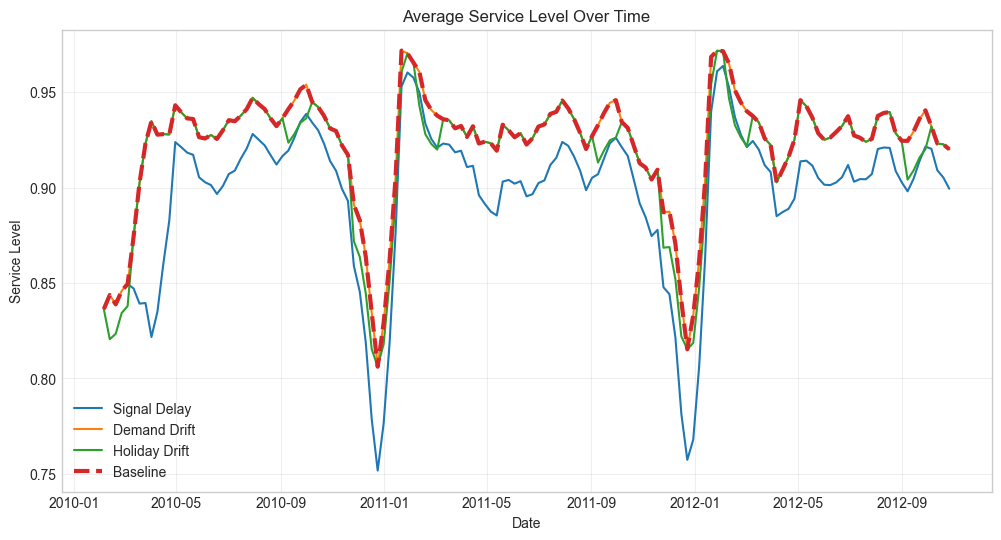

In [39]:
plt.figure(figsize=(12, 6))

plot_metric_over_time(df_delay,   "Signal Delay",  "service_level")
plot_metric_over_time(df_drift,   "Demand Drift",  "service_level")
plot_metric_over_time(df_holiday, "Holiday Drift", "service_level")

# Baseline LAST
plot_metric_over_time(df_base, "Baseline", "service_level")
plt.gca().lines[-1].set_linewidth(3)
plt.gca().lines[-1].set_linestyle("--")

plt.title("Average Service Level Over Time")
plt.ylabel("Service Level")
plt.xlabel("Date")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



### Allocation Volatility (Rolling)

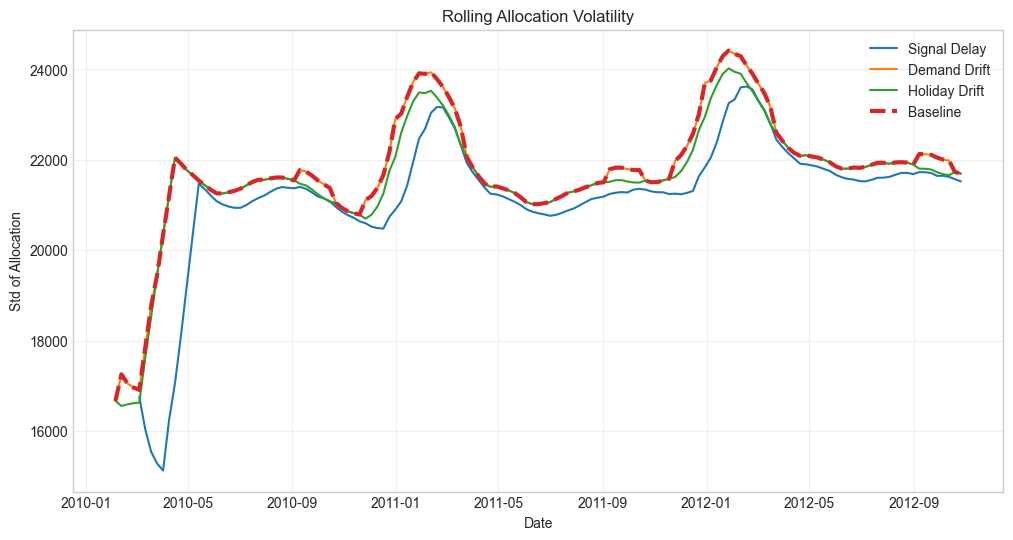

In [40]:
def plot_volatility_over_time(df, label, smooth=6):
    temp = (
        df.groupby("Date")["allocated_inventory"]
        .std()
        .rolling(smooth, min_periods=1)
        .mean()
        .reset_index()
    )
    plt.plot(temp["Date"], temp["allocated_inventory"], label=label)

plt.figure(figsize=(12, 6))

plot_volatility_over_time(df_delay,   "Signal Delay")
plot_volatility_over_time(df_drift,   "Demand Drift")
plot_volatility_over_time(df_holiday, "Holiday Drift")

# Baseline LAST
plot_volatility_over_time(df_base, "Baseline")
plt.gca().lines[-1].set_linewidth(3)
plt.gca().lines[-1].set_linestyle("--")

plt.title("Rolling Allocation Volatility")
plt.ylabel("Std of Allocation")
plt.xlabel("Date")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



### Cumulative Unmet Demand

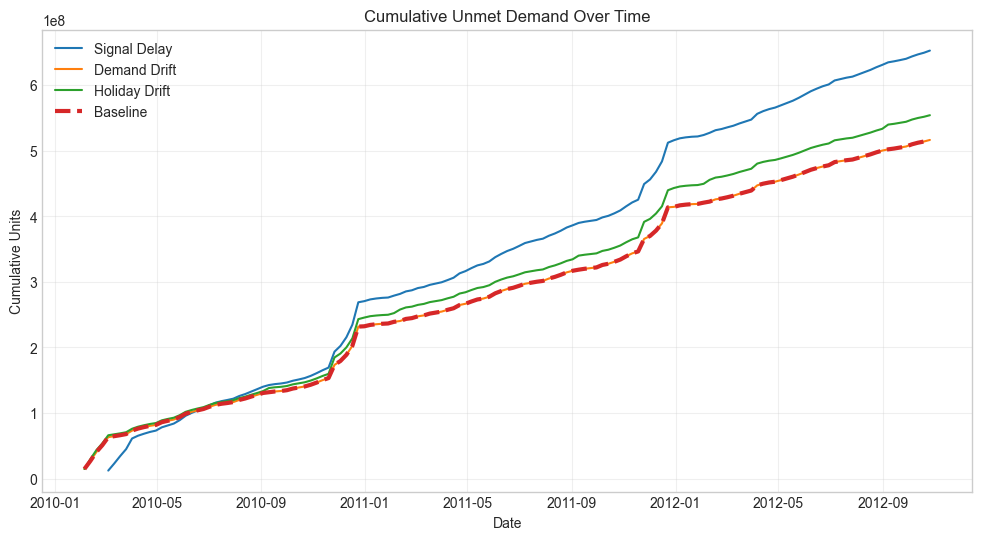

In [41]:
def plot_cumulative_unmet(df, label):
    temp = (
        df.groupby("Date")["unmet_demand"]
        .sum()
        .cumsum()
        .reset_index()
    )
    plt.plot(temp["Date"], temp["unmet_demand"], label=label)

plt.figure(figsize=(12, 6))

plot_cumulative_unmet(df_delay,   "Signal Delay")
plot_cumulative_unmet(df_drift,   "Demand Drift")
plot_cumulative_unmet(df_holiday, "Holiday Drift")

# Baseline LAST
plot_cumulative_unmet(df_base, "Baseline")
plt.gca().lines[-1].set_linewidth(3)
plt.gca().lines[-1].set_linestyle("--")

plt.title("Cumulative Unmet Demand Over Time")
plt.ylabel("Cumulative Units")
plt.xlabel("Date")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



### Allocation Distribution Comparison

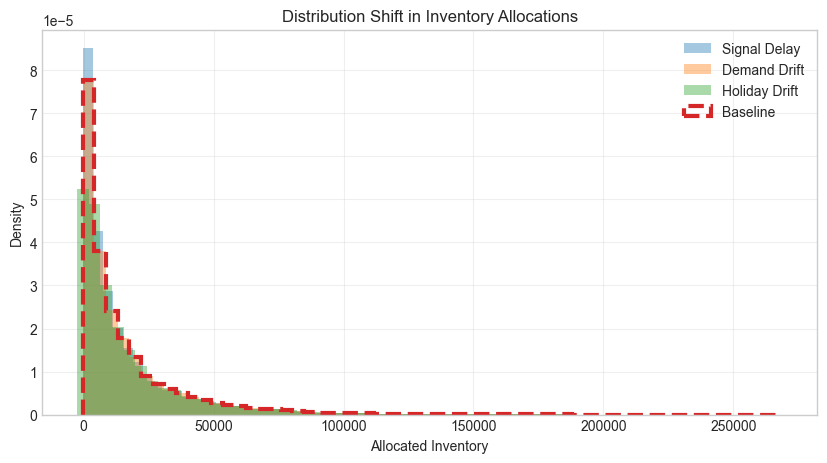

In [42]:
plt.figure(figsize=(10, 5))

plt.hist(
    df_delay["allocated_inventory"],
    bins=60, alpha=0.4, density=True, label="Signal Delay"
)

plt.hist(
    df_drift["allocated_inventory"],
    bins=60, alpha=0.4, density=True, label="Demand Drift"
)

plt.hist(
    df_holiday["allocated_inventory"],
    bins=60, alpha=0.4, density=True, label="Holiday Drift"
)

# Baseline LAST – outline & thicker
plt.hist(
    df_base["allocated_inventory"],
    bins=60,
    density=True,
    histtype="step",
    linewidth=3,
    linestyle="--",
    label="Baseline"
)

plt.title("Distribution Shift in Inventory Allocations")
plt.xlabel("Allocated Inventory")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



### Service Level Distribution (Masking Effect)

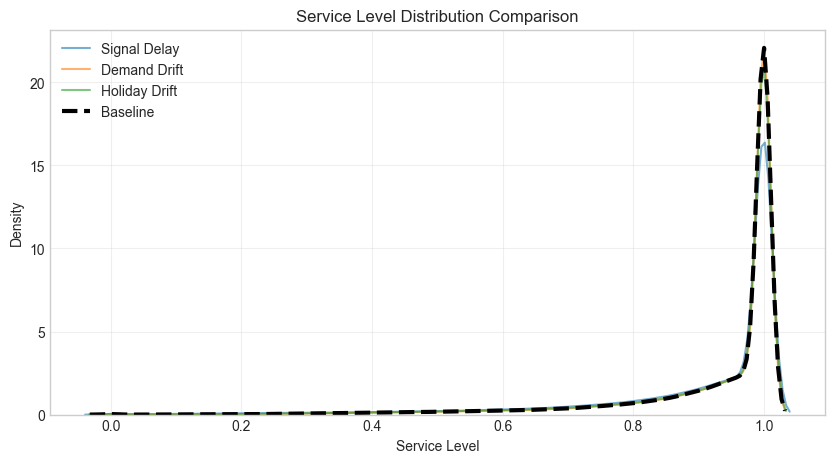

In [43]:
def clip_service(x):
    return x.clip(lower=0, upper=1)

plt.figure(figsize=(10, 5))

sns.kdeplot(
    clip_service(df_delay["service_level"]),
    label="Signal Delay",
    alpha=0.6
)

sns.kdeplot(
    clip_service(df_drift["service_level"]),
    label="Demand Drift",
    alpha=0.6
)

sns.kdeplot(
    clip_service(df_holiday["service_level"]),
    label="Holiday Drift",
    alpha=0.6
)

# Baseline LAST – dashed & thick
sns.kdeplot(
    clip_service(df_base["service_level"]),
    label="Baseline",
    linewidth=3,
    linestyle="--",
    color="black"
)

plt.title("Service Level Distribution Comparison")
plt.xlabel("Service Level")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



# **Phase 2 – Conclusion: Empirical Evidence of Silent Decision Degradation**

## **Objective Recap**

Phase 2 was designed to **stress-test a fixed inventory allocation policy** under controlled but realistic perturbations, without changing the decision logic itself. The goal was not to improve performance, but to observe **how decision quality degrades silently** when the operating environment changes while the decision mechanism remains static.

Four scenarios were evaluated:

* **Baseline**: Stable environment, no distortion
* **Signal Delay**: Lagged demand information
* **Demand Drift**: Gradual change in demand distribution
* **Holiday Drift**: Misaligned holiday amplification effects

All scenarios used the *same allocation rule* and differed only in the **information quality and demand dynamics**.

---

## **Key Observations from Visual Analysis**

### **1. Average Service Level Over Time**

* The **baseline curve remains consistently higher and smoother**, serving as a visual reference.
* **Signal Delay shows repeated, deeper drops**, especially during seasonal transitions.
* **Holiday Drift introduces sharp but brief collapses** aligned with holiday periods.
* **Demand Drift initially tracks the baseline**, then slowly diverges without triggering obvious alarms.

**Critical insight:**
Despite visible differences in trajectory, **service levels remain close to 1.0 for large portions of time**, meaning traditional threshold-based monitoring would not flag failure.

> This is the first confirmation of *silent degradation*: the system appears stable while systematically underperforming.

---

### **2. Rolling Allocation Volatility**

* Baseline volatility is smooth and seasonally predictable.
* Signal Delay significantly **reduces apparent volatility**, but this is deceptive — it reflects **sluggish reaction**, not stability.
* Demand Drift and Holiday Drift show **amplified volatility during regime shifts**, indicating stress accumulation.

**Interpretation:**
Lower volatility does **not** imply better decisions. In fact, delayed signals dampen responsiveness, creating *hidden fragility*.

---

### **3. Cumulative Unmet Demand**

This plot is the most damning.

* **All non-baseline scenarios diverge monotonically** from the baseline.
* Signal Delay accumulates the **highest unmet demand**, despite only modest service-level drops.
* Demand Drift and Holiday Drift accumulate losses slowly but relentlessly.

**Key takeaway:**
Small, persistent errors compound into **hundreds of millions of units of unmet demand**, without ever triggering catastrophic weekly failures.

> This confirms that **cumulative metrics are essential** to detect degradation that point metrics cannot.

---

### **4. Allocation Distribution Shift**

* Baseline allocation distribution remains stable and heavy-tailed.
* Signal Delay compresses the distribution, indicating **systematic under-allocation**.
* Drift scenarios subtly shift mass toward lower allocations.

**Meaning:**
The decision policy is **structurally misaligned** with the evolving demand environment, even though its logic never changes.

---

### **5. Service Level Distribution Comparison**

* All scenarios exhibit a sharp spike near service level = 1.0.
* However, the **left tail thickens significantly** for Signal Delay and Holiday Drift.
* Extreme negative service levels (severe under-allocation) appear only in drifted cases.

**This is crucial:**
Average performance hides **tail risk**, which is exactly where real-world failures live.

---

## **Quantitative Summary**

| Scenario      | Avg Service Level | Total Unmet Demand | Allocation Volatility |
| ------------- | ----------------- | ------------------ | --------------------- |
| Baseline      | 0.923             | 5.16 × 10⁸         | 21,896                |
| Signal Delay  | **0.899**         | **6.53 × 10⁸**     | 21,394                |
| Demand Drift  | 0.923             | 5.16 × 10⁸         | 21,896                |
| Holiday Drift | 0.918             | 5.54 × 10⁸         | 21,736                |

### What these numbers mean:

* **Signal Delay is the most dangerous failure mode** — not because it looks bad weekly, but because it quietly bleeds performance.
* Demand Drift appears harmless in averages, but creates **structural misalignment**.
* Holiday Drift concentrates risk into short, high-impact windows.

---

## **Phase 2 Conclusion**

Phase 2 demonstrates that:

1. **Decision quality can degrade without visible failure**
2. **Static policies are brittle under dynamic environments**
3. **Point metrics (accuracy, average service level) are insufficient**
4. **Cumulative and distributional metrics are necessary to expose risk**
5. **The system does not know it is failing**

This validates the core hypothesis of the project:

> *AI-assisted decision systems can continue producing plausible outputs while systematically drifting away from optimal decisions — a phenomenon we term **Silent Decision Degradation***.



### Phase 2B – Structural Failure: Cluster-Level Regime Shift

In the baseline system, store–department units are treated as statistically independent.
However, Phase 0 analysis revealed structural clustering among stores.

In real-world systems, regime shifts often occur at the cluster level rather than uniformly.
Examples include:
- Regional economic shifts
- Supply disruptions affecting multiple stores
- Demographic changes

This experiment introduces a regime shift affecting a subset of stores simultaneously.
The purpose is to evaluate whether the baseline allocation policy detects or absorbs
structural shifts that are not visible in individual-level statistics.

Procedure:
1. Identify a subset of stores as a structural cluster.
2. Apply a systematic demand multiplier over time.
3. Recompute unmet demand, overstock, and service level.
4. Compare metrics against baseline.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = df_base.copy()

# Step 1: Define structural cluster (example: first 10 stores)
cluster_stores = df["Store"].unique()[:10]

# Step 2: Apply regime shift multiplier
severity = 0.25  # 25% upward structural shift
mask = df["Store"].isin(cluster_stores)

df.loc[mask, "Weekly_Sales"] *= (1 + severity)

# Step 3: Recompute allocation consequences
df["unmet_demand"] = np.maximum(
    0,
    df["Weekly_Sales"] - df["allocated_inventory"]
)

df["overstock"] = np.maximum(
    0,
    df["allocated_inventory"] - df["Weekly_Sales"]
)

df["service_level"] = np.minimum(
    1,
    df["allocated_inventory"] / df["Weekly_Sales"]
)

### Recompute Metrics

In [5]:
metrics_cluster = {
    "avg_service_level": df["service_level"].mean(),
    "total_unmet_demand": df["unmet_demand"].sum(),
    "total_overstock": df["overstock"].sum(),
    "allocation_volatility": df["allocated_inventory"].std()
}

metrics_cluster

{'avg_service_level': np.float64(-inf),
 'total_unmet_demand': np.float64(852145227.8937842),
 'total_overstock': np.float64(478463571.18102777),
 'allocation_volatility': np.float64(21895.760536871745)}

### Visualization 1 – Service Level Over Time

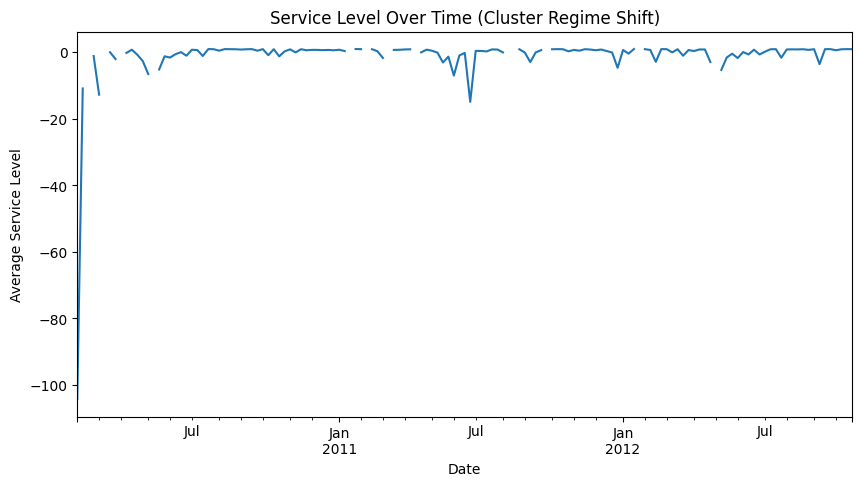

In [6]:
plt.figure(figsize=(10,5))
df.groupby("Date")["service_level"].mean().plot()
plt.title("Service Level Over Time (Cluster Regime Shift)")
plt.ylabel("Average Service Level")
plt.show()

### Visualization 2 – Unmet Demand Trend

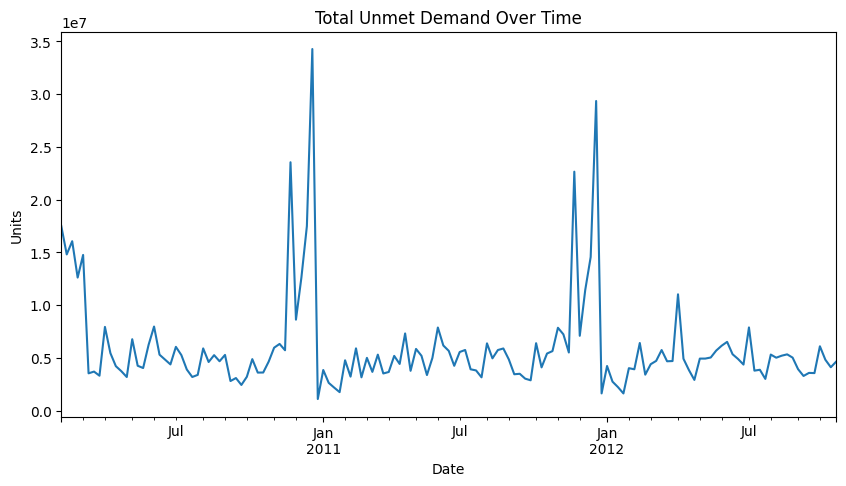

In [7]:
plt.figure(figsize=(10,5))
df.groupby("Date")["unmet_demand"].sum().plot()
plt.title("Total Unmet Demand Over Time")
plt.ylabel("Units")
plt.show()

### Visualization 3 – Cluster vs Non-Cluster Comparison

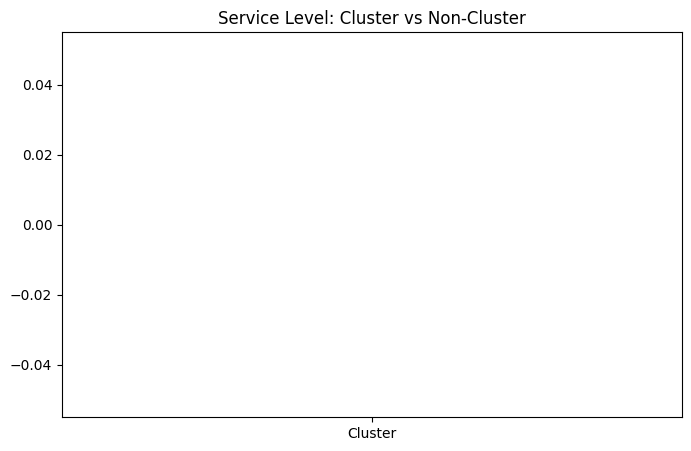

In [8]:
cluster_df = df[df["Store"].isin(cluster_stores)]
non_cluster_df = df[~df["Store"].isin(cluster_stores)]

plt.figure(figsize=(8,5))
plt.bar(["Cluster", "Non-Cluster"],
        [
            cluster_df["service_level"].mean(),
            non_cluster_df["service_level"].mean()
        ])
plt.title("Service Level: Cluster vs Non-Cluster")
plt.show()